# General imports

In [ ]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

from propflow import SnapshotAnalyzer, AnalysisReport, SnapshotVisualizer 
from propflow.bp.engine_base import BPEngine

from propflow.configs import create_random_int_table
from propflow.utils.fg_utils import FGBuilder

# generate the Factor Graph:

/Users/or/Projects/Belief-Propagation-Simulator/src/propflow/snapshots/visualizer.py:1038: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


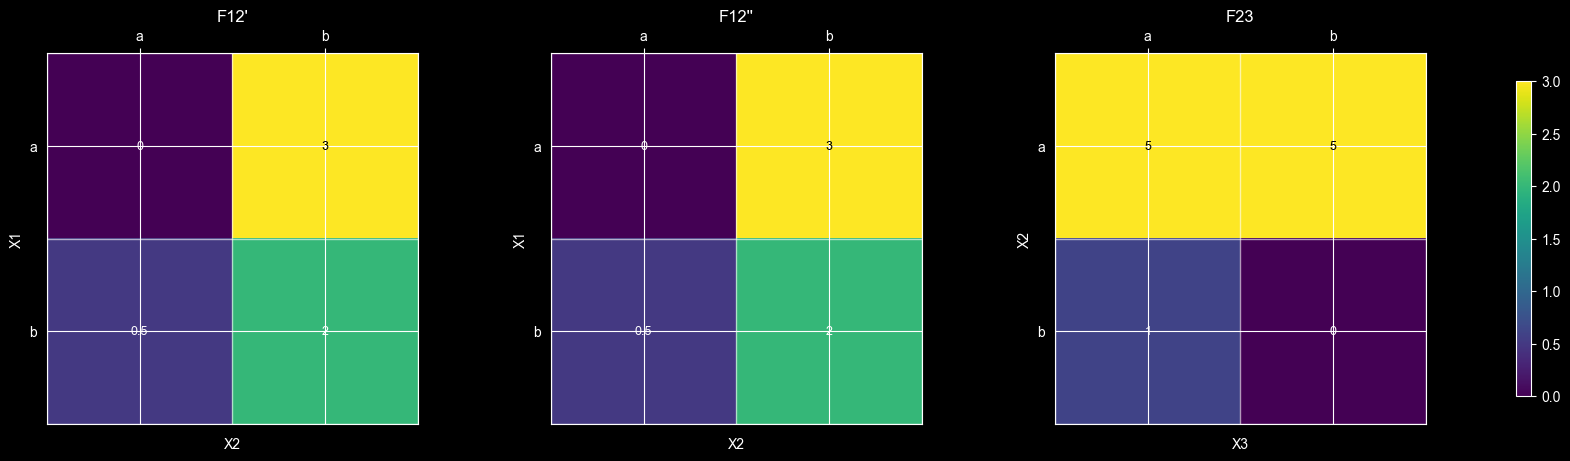

In [2]:
np.random.seed(7)

RUN_DIR = Path("results/notebooks/lemniscate_all_utils")
RUN_DIR.mkdir(parents=True, exist_ok=True)
from propflow import FactorAgent,VariableAgent
from propflow.core.components import CostTable
from propflow.policies import split_specific_factors

C12 : CostTable = np.array([[0,1]
                            ,[6,4]]).T
C23 : CostTable = np.array([[5,1],
                            [5,0]]).T
f12 = FactorAgent.create_from_cost_table("F12", cost_table=C12)
f23 = FactorAgent.create_from_cost_table("F23", cost_table=C23)
X1 = VariableAgent("X1", domain=2)
X2 = VariableAgent("X2", domain=2)
X3 = VariableAgent("X3", domain=2)


chain = FGBuilder.build_from_edges(
    variables=[X1, X2, X3],
    factors=[f12, f23],
    edges={f12: [X1, X2], f23: [X2, X3]},)
graph_split = FGBuilder.build_from_edges(
    variables=[X1, X2, X3],
    factors=[f12, f23],
    edges={f12: [X1, X2], f23: [X2, X3]},
)
split_specific_factors(graph_split, [f12])


engine = BPEngine(graph_split)
engine.run(max_iter=10)
vis = SnapshotVisualizer(engine.snapshots)
CS = vis.plot_cost_tables()

0 3.0
[3.  1.5]


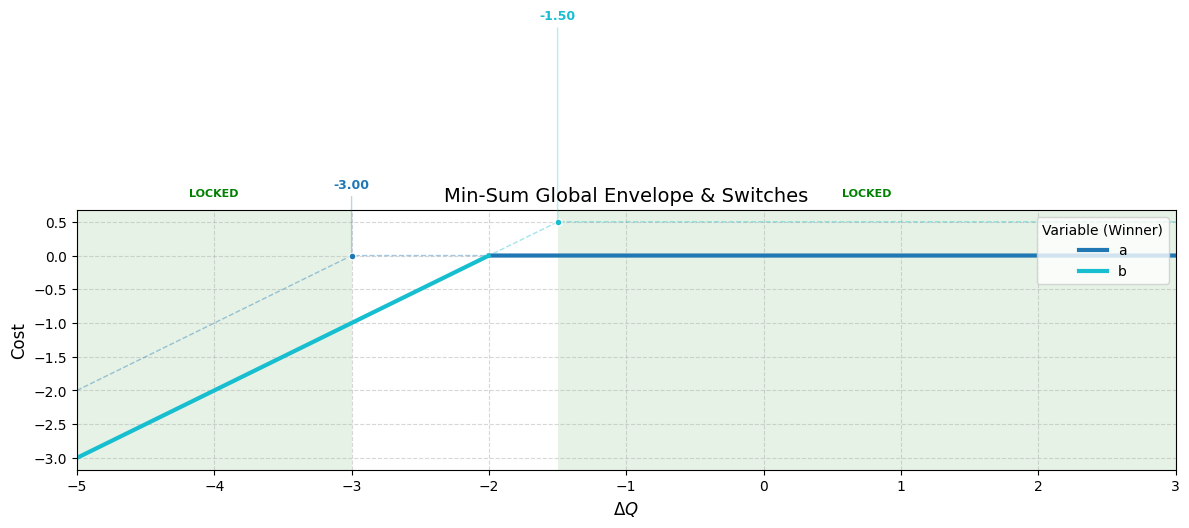

In [4]:
from typing import Tuple
from utils import plot_gap_preserved_regions
import numpy as np
def max_difference(arr:np.ndarray,axis:int)-> Tuple[int,int]:
    """
    Finds the label b that maximizes c[a,b] - c[a,a]
    """
    diag = np.diag(arr)
    if axis == 0:
        diff = arr - diag
    else:
        diff = arr - diag[:, None]
    max_diff_idx = np.argmax(np.max(diff, axis=axis))
    max_diff = np.max(diff)
    return axis,max_diff, max_diff_idx

axis,diff,idx = max_difference(graph_split.factors[1].cost_table, axis=1)
print(idx,diff)
delta_qs = np.arange(-10,10,0.1)
C12_tag = C12.copy() /2
all_diffs = C12_tag[:,int(1-idx)] - C12_tag[:,int(idx)]
all_diffs = C12_tag[:,int(1-idx)] - C12_tag[:,int(idx)]
print(all_diffs)
plot_gap_preserved_regions(C12_tag,delta_q_range=(-5,3),axis = 1)



Factor 'f12' does not have explicit row/col connection info.
x1 \ x2  a   b  c
a        0   5  2
b        5   1  5
c        10  5  2


/Users/or/Projects/Belief-Propagation-Simulator/src/propflow/snapshots/visualizer.py:414: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


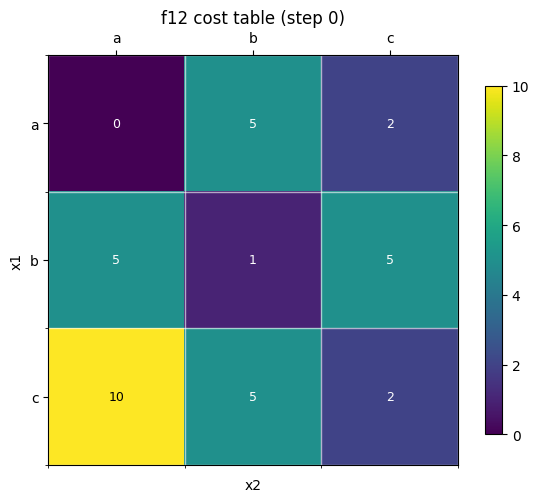

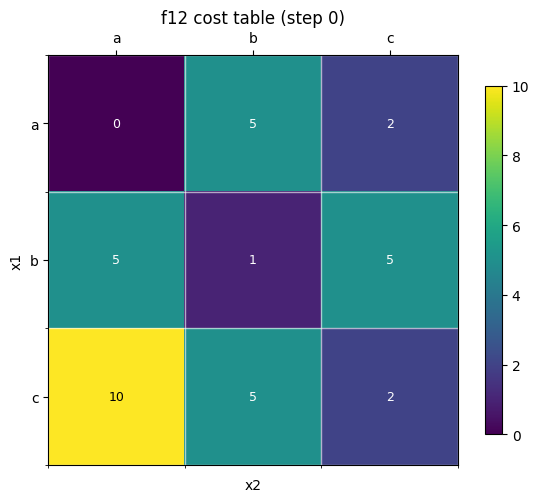

In [4]:
from propflow import SnapshotVisualizer

from propflow.core.agents import FactorAgent
matrix_3x3 = [
    [0,  5, 2], 
    [5,  1,  5], 
    [10, 5,  2]   
]

f12 = FactorAgent.create_from_cost_table("f12", np.array(matrix_3x3))
SnapshotVisualizer.plot_agent_cost_table(f12)

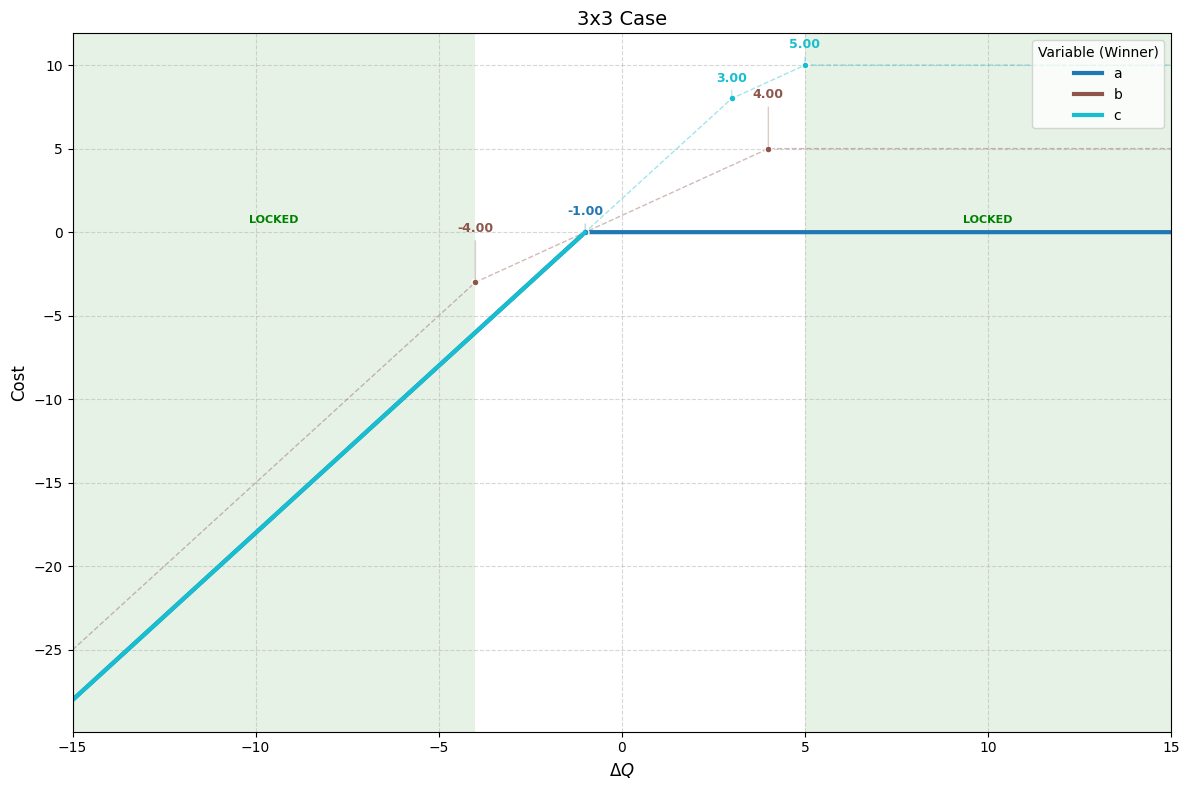

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from utils import plot_gap_preserved_regions

# This should highlight the far left AND the far right, leaving the middle white.
plot_gap_preserved_regions(matrix_3x3, axis=1, delta_q_range=(-15, 15), 
                           title="3x3 Case")